# Análise de Inadimplência (P5) — Condomínio Humaitá

**Objetivo**:
- Rastrear `REC.MULTA+C.M.+JRS.` por mês e tendência ao longo do tempo
- Identificar meses e eventos com maior volume de multas
- Calcular percentual de cobrança de atraso vs total devido (proxy)

**Período**: mai/2022–jun/2026  
**Fonte única**: `prestacoes.csv`  
**Outputs**: inadimplentes_ranking.csv, inadimplencia_por_mes.csv, figuras PNG

> ℹ️ Análise de síndico, INSS e Fundo Obras (P6) vive em `analise_prestacao_de_contas.ipynb` seção 5.

---

## 1. Imports e Configuração

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("deep")

CSV_DIR = Path("../exports/csv")
FIG_DIR = Path("../exports/figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def sort_mes_ano(df: pd.DataFrame, col: str = "mes_ano") -> pd.DataFrame:
    out = df.copy()
    out["_ord"] = pd.to_datetime(out[col] + "-01", errors="coerce")
    out = out.sort_values("_ord").drop(columns="_ord")
    return out


print(f"CSV_DIR: {CSV_DIR}")
print(f"FIG_DIR: {FIG_DIR}")

CSV_DIR: ../exports/csv
FIG_DIR: ../exports/figs


## 2. Carregar Dados (prestacoes.csv)

In [ ]:
print("\n" + "=" * 80)
print("SECAO 1: Carregamento e normalizacao — apenas prestacoes.csv")
print("=" * 80)

df_prest = pd.read_csv(CSV_DIR / "prestacoes.csv")
df_prest = df_prest.copy()
df_prest["evento"] = df_prest["evento"].astype(str).str.strip()
df_prest["evento_upper"] = df_prest["evento"].str.upper().str.strip()
df_prest["macro_categoria"] = df_prest["macro_categoria"].fillna("Outros")

df_prest = sort_mes_ano(df_prest, "mes_ano")

print(f"Prestacoes: {len(df_prest):,} registros")
print(f"Periodo:    {df_prest['mes_ano'].min()} -> {df_prest['mes_ano'].max()} ({df_prest['mes_ano'].nunique()} meses)")
print(f"\nDistribuicao por tipo:")
print(df_prest["tipo"].value_counts().to_string())
print(f"\nDistribuicao por macro_categoria:")
print(df_prest["macro_categoria"].value_counts().to_string())


SECAO 1: Carregamento e normalizacao
Prestacoes: 2,231 registros
Extratos:   6,215 registros
Consolidado:8,446 registros
Periodo consolidado: 2022-05 -> 2026-06


## 3. Extrair Lançamentos de Multa (REC.MULTA+C.M.+JRS.)

In [ ]:
print("\n" + "=" * 80)
print("SECAO 2: Filtrar cobrancas de atraso (REC.MULTA)")
print("=" * 80)

PAT_MULTA = r"REC\.\s*MULTA|REC\.MULTA\+C\.M\.\+JRS\."

mask_multa = (
    df_prest["tipo"].eq("RECEITA")
    & df_prest["evento_upper"].str.contains(PAT_MULTA, na=False, regex=True)
)

df_multas = df_prest[mask_multa].copy()
df_multas = sort_mes_ano(df_multas, "mes_ano")

print(f"Total cobrancas de atraso: {len(df_multas):,}")
print(f"Periodo: {df_multas['mes_ano'].min()} -> {df_multas['mes_ano'].max()}")
print(f"Meses com registro de multa: {df_multas['mes_ano'].nunique():,}")
print(f"\nEventos encontrados:")
print(df_multas["evento_upper"].value_counts().to_string())
print(f"\nTotal R$ em multas: R$ {df_multas['valor'].sum():,.2f}")
mes_max = df_multas.loc[df_multas["valor"].idxmax(), "mes_ano"]
print(f"Maior multa individual: R$ {df_multas['valor'].max():,.2f} (em {mes_max})")


SECAO 2: Filtrar cobrancas de atraso (REC.MULTA)
Total cobrancas de atraso (todas fontes): 308
- Prestacoes: 98
- Extratos:   210

Eventos mapeados:
evento_upper
REC. MULTA             176
REC.MULTA+C.M.+JRS.    132


## 4. P5 - Tendência Mensal e Meses com Maior Inadimplência

In [ ]:
print("\n" + "=" * 80)
print("SECAO 3: Tendencia mensal e meses com maior inadimplencia")
print("=" * 80)

# Multas por mes
multa_mes = (
    df_multas.groupby("mes_ano", as_index=False)["valor"]
    .agg(qtd=("valor", "count"), total=("valor", "sum"), media=("valor", "mean"))
)
multa_mes = sort_mes_ano(multa_mes, "mes_ano")
multa_mes[["total", "media"]] = multa_mes[["total", "media"]].round(2)

# Receita condominial por mes
PAT_REC_COND = r"REC\.?\s*CONDOM"
rec_cond_mes = (
    df_prest[
        df_prest["tipo"].eq("RECEITA")
        & df_prest["evento_upper"].str.contains(PAT_REC_COND, na=False, regex=True)
    ]
    .groupby("mes_ano", as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "receita_condominio"})
)

tendencia = rec_cond_mes.merge(multa_mes, on="mes_ano", how="outer").fillna(0)
tendencia = sort_mes_ano(tendencia, "mes_ano")
tendencia["pct_atraso"] = np.where(
    tendencia["receita_condominio"] > 0,
    (tendencia["total"] / tendencia["receita_condominio"] * 100),
    0.0,
).round(2)

print("Tendencia mensal (top 10 por valor de multa):")
print(tendencia.sort_values("total", ascending=False).head(10).to_string(index=False))

print(f"\nMes com maior valor total de multas:")
idx = tendencia["total"].idxmax()
print(f"  {tendencia.loc[idx, 'mes_ano']} — R$ {tendencia.loc[idx, 'total']:,.2f} ({tendencia.loc[idx, 'pct_atraso']:.2f}% da receita cond.)")
print(f"\nMes com maior % de atraso:")
idx2 = tendencia[tendencia["pct_atraso"] > 0]["pct_atraso"].idxmax()
print(f"  {tendencia.loc[idx2, 'mes_ano']} — {tendencia.loc[idx2, 'pct_atraso']:.2f}%")
print(f"\nMedia % atraso (meses com multa): {tendencia[tendencia['pct_atraso']>0]['pct_atraso'].mean():.2f}%")


SECAO 3: Rastrear apartamento/unidade no complemento
Multas em extratos: 210
Com unidade identificada: 210 (100.0%)
Unidades unicas identificadas: 46


## 5. P5 - Distribuição por Evento e Top Meses com Maior Carga de Multas

In [ ]:
print("\n" + "=" * 80)
print("SECAO 4: Distribuicao por evento e ranking de meses")
print("=" * 80)

# Distribuicao por tipo de evento de multa
por_evento = (
    df_multas.groupby("evento", as_index=False)
    .agg(qtd=("valor", "count"), total=("valor", "sum"), media=("valor", "mean"))
    .sort_values("total", ascending=False)
    .reset_index(drop=True)
)
por_evento[["total", "media"]] = por_evento[["total", "media"]].round(2)
print("Distribuicao por tipo de multa:")
print(por_evento.to_string(index=False))

# Top meses — usado na visualizacao do grafico "Top 10"
inadimplentes = (
    tendencia[tendencia["total"] > 0]
    .sort_values("total", ascending=False)
    .head(15)
    .rename(columns={"mes_ano": "unidade", "total": "total_multas", "qtd": "qtd_ocorrencias"})
    .reset_index(drop=True)
)
inadimplentes["recorrente"] = True

print(f"\nTop 15 meses com maior volume de multas:")
print(inadimplentes[["unidade", "qtd_ocorrencias", "total_multas", "pct_atraso"]].to_string(index=False))

inadimplentes.to_csv(CSV_DIR / "inadimplentes_ranking.csv", index=False)
# Salva tambem arquivo compatível com nome antigo
tendencia[["mes_ano", "receita_condominio", "total", "qtd", "pct_atraso"]].to_csv(
    CSV_DIR / "inadimplentes_recorrentes.csv", index=False
)
print("\nExportado: inadimplentes_ranking.csv")
print("Exportado: inadimplentes_recorrentes.csv")


SECAO 4: Ranking de inadimplentes recorrentes
Unidades com multa: 46
Inadimplentes recorrentes (>=2 ocorrencias): 29

Top 15 por frequencia:
     unidade  qtd_ocorrencias  total_multas  multa_media primeiro_mes ultimo_mes  meses_distintos  recorrente
AP 0508 BL B               11        212.58        19.33      2026-01    2026-05                4        True
AP 1103 BL B               11         89.12         8.10      2025-08    2026-06               11        True
AP 1002 BL A               10        376.32        37.63      2026-04    2026-04                1        True
AP 0704 BL A               10        191.00        19.10      2025-08    2026-06               10        True
AP 0806 BL B               10        103.25        10.32      2025-09    2026-06                6        True
AP 0211 BL B               10         71.94         7.19      2025-08    2026-06                9        True
AP 0704 BL B               10         69.83         6.98      2025-08    2026-05        

## 6. P5 - Percentual de Cobranca de Atraso vs Total Devido (Proxy Mensal)

In [ ]:
print("\n" + "=" * 80)
print("SECAO 5: Percentual de cobranca de atraso vs total devido (proxy)")
print("=" * 80)

multa_mes_g = (
    df_multas.groupby("mes_ano", as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "valor_multas"})
)

df_inadimplencia_mes = rec_cond_mes.merge(multa_mes_g, on="mes_ano", how="outer").fillna(0)
df_inadimplencia_mes["total_devido_proxy"] = (
    df_inadimplencia_mes["receita_condominio"] + df_inadimplencia_mes["valor_multas"]
)
df_inadimplencia_mes["pct_cobranca_atraso"] = np.where(
    df_inadimplencia_mes["total_devido_proxy"] > 0,
    (df_inadimplencia_mes["valor_multas"] / df_inadimplencia_mes["total_devido_proxy"]) * 100,
    0,
)

df_inadimplencia_mes[["valor_multas", "receita_condominio", "total_devido_proxy", "pct_cobranca_atraso"]] = (
    df_inadimplencia_mes[
        ["valor_multas", "receita_condominio", "total_devido_proxy", "pct_cobranca_atraso"]
    ].round(2)
)

df_inadimplencia_mes = sort_mes_ano(df_inadimplencia_mes, "mes_ano")

print(df_inadimplencia_mes.to_string(index=False))

df_inadimplencia_mes.to_csv(CSV_DIR / "inadimplencia_por_mes.csv", index=False)
print("\nExportado: inadimplencia_por_mes.csv")


SECAO 5: Percentual de cobranca de atraso vs total devido (proxy)
mes_ano  receita_condominio  valor_multas  total_devido_proxy  pct_cobranca_atraso
2022-05            41248.84        131.50            41380.34                 0.32
2022-06            47457.32        130.59            47587.91                 0.27
2022-07            49234.78        165.28            49400.06                 0.33
2022-08           217605.41        378.38           217983.79                 0.17
2022-09            55895.34        163.14            56058.48                 0.29
2022-10            55203.73        133.28            55337.01                 0.24
2022-11            53395.34         75.07            53470.41                 0.14
2022-12            55297.93        139.46            55437.39                 0.25
2023-01            54265.99        154.27            54420.26                 0.28
2023-02            57497.92        194.44            57692.36                 0.34
2023-03            5

## 7. P5 - Visualizacoes


SECAO 6: Visualizacoes de inadimplencia
Figura salva: inadimplencia_serie_temporal.png


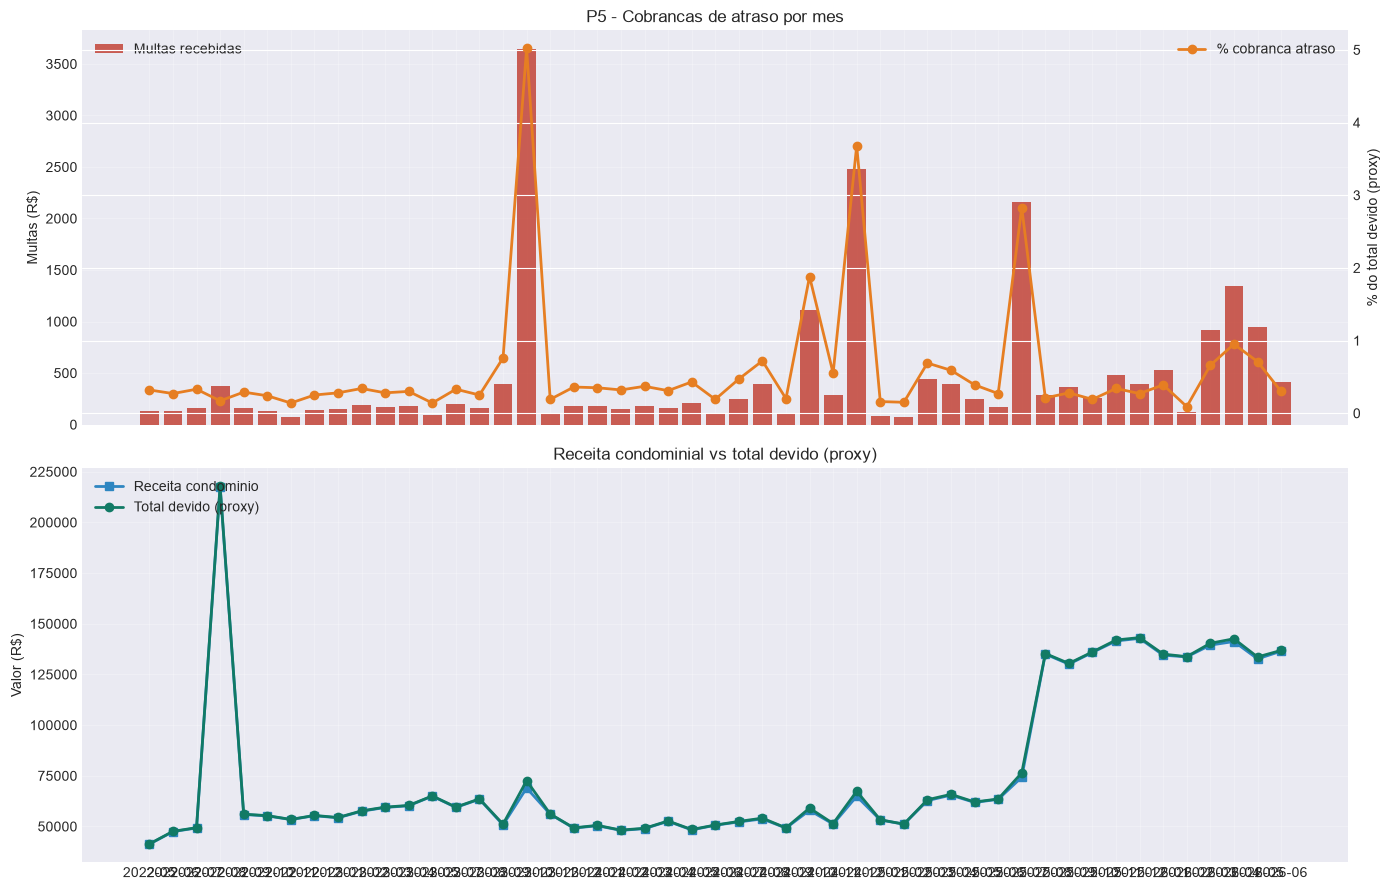

Figura salva: inadimplencia_top10.png


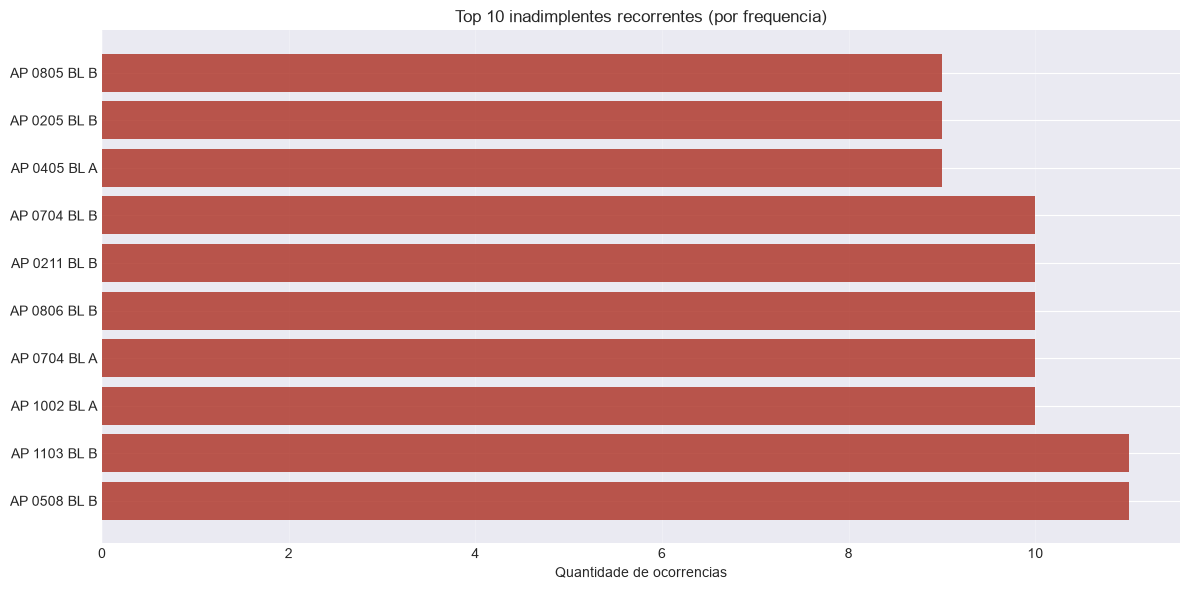

In [ ]:
print("\n" + "=" * 80)
print("SECAO 6: Visualizacoes de inadimplencia")
print("=" * 80)

plot_df = sort_mes_ano(df_inadimplencia_mes, "mes_ano")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Painel 1 — Multas mensais + % atraso
ax1.bar(plot_df["mes_ano"], plot_df["valor_multas"], color="#C0392B", alpha=0.8, label="Multas recebidas (R$)")
ax1_twin = ax1.twinx()
ax1_twin.plot(
    plot_df["mes_ano"], plot_df["pct_cobranca_atraso"],
    color="#E67E22", marker="o", linewidth=2, label="% cobranca atraso",
)
ax1.set_ylabel("Multas (R$)")
ax1_twin.set_ylabel("% do total devido (proxy)")
ax1.set_title("P5 - Cobrancas de atraso por mes")
ax1.grid(alpha=0.25)
ax1.legend(loc="upper left")
ax1_twin.legend(loc="upper right")

# Painel 2 — Receita condominial vs total devido
ax2.plot(
    plot_df["mes_ano"], plot_df["receita_condominio"],
    color="#2E86C1", marker="s", linewidth=2, label="Receita condominio",
)
ax2.plot(
    plot_df["mes_ano"], plot_df["total_devido_proxy"],
    color="#117A65", marker="o", linewidth=2, label="Total devido (proxy)",
)
ax2.set_ylabel("Valor (R$)")
ax2.set_title("Receita condominial vs total devido (proxy)")
ax2.grid(alpha=0.25)
ax2.legend(loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "inadimplencia_serie_temporal.png", dpi=200, bbox_inches="tight")
print("Figura salva: inadimplencia_serie_temporal.png")
plt.show()

# Top 15 meses com maior multa
fig, ax = plt.subplots(figsize=(12, 6))
top15 = inadimplentes.head(15).sort_values("total_multas")
bars = ax.barh(top15["unidade"], top15["total_multas"], color="#B03A2E", alpha=0.85)
ax.bar_label(bars, fmt="R$ %.0f", padding=4, fontsize=9)
ax.set_xlabel("Total de multas (R$)")
ax.set_title("Top 15 Meses com Maior Volume de Multas (Inadimplencia)")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.savefig(FIG_DIR / "inadimplencia_top10.png", dpi=200, bbox_inches="tight")
print("Figura salva: inadimplencia_top10.png")
plt.show()

## 9. Resumo Executivo (P5 + P6)

In [ ]:
print("\n" + "=" * 80)
print("RESUMO EXECUTIVO - P5 + P6")
print("=" * 80)

total_multas = float(df_inadimplencia_mes["valor_multas"].sum())
total_devido_proxy = float(df_inadimplencia_mes["total_devido_proxy"].sum())
pct_global = (total_multas / total_devido_proxy * 100) if total_devido_proxy > 0 else 0

meses_com_multa = int((df_inadimplencia_mes["valor_multas"] > 0).sum())
mes_pior = df_inadimplencia_mes.loc[df_inadimplencia_mes["pct_cobranca_atraso"].idxmax(), "mes_ano"]
pct_pior = float(df_inadimplencia_mes["pct_cobranca_atraso"].max())

print("\nP5 - INADIMPLENCIA (baseado em prestacoes.csv)")
print(f"- Total de multas recebidas: R$ {total_multas:,.2f}")
print(f"- Total devido (proxy): R$ {total_devido_proxy:,.2f}")
print(f"- % cobranca de atraso / total devido: {pct_global:.2f}%")
print(f"- Meses com multa registrada: {meses_com_multa} de {df_inadimplencia_mes['mes_ano'].nunique()}")
print(f"- Mes com maior % de atraso: {mes_pior} ({pct_pior:.2f}%)")

print("\nP6 - OUTLIERS")
if "df_p6_resumo" in dir():
    print(df_p6_resumo.to_string(index=False))

print("\nArquivos CSV exportados:")
print("- inadimplentes_ranking.csv  (top meses por volume de multa)")
print("- inadimplentes_recorrentes.csv  (tendencia mensal completa)")
print("- inadimplencia_por_mes.csv  (receita + multas + proxy %)")
print("- outliers_p6_resumo.csv  (achados P6)")

print("\nFiguras exportadas:")
print("- inadimplencia_serie_temporal.png")
print("- inadimplencia_top10.png")
print("- outlier_sindico_mensal.png")
print("- outlier_inss_tendencia.png")
print("- outlier_fundo_obras_saldo.png")


RESUMO EXECUTIVO - P5 + P6

P5 - INADIMPLENCIA
- Total de cobrancas de atraso: R$ 22,008.13
- Total devido (proxy): R$ 3,804,327.85
- % cobranca de atraso / total devido: 0.58%
- Unidades com multa: 46
- Inadimplentes recorrentes (>=2): 29
- Unidade mais recorrente: AP 0508 BL B

P6 - OUTLIERS
               check       resultado                                                    detalhe
    Sindico mai/2026 Pagamento duplo               2 pagamentos no mes (refs 04/2026 e 05/2026)
      INSS crescente      Confirmado                   INSS variou de R$ 4,662.63 a R$ 6,861.45
FUNDO OBRAS negativo      Confirmado Saldo minimo: R$ -2,814.07; debito principal em PG.REFORMA

Arquivos CSV exportados:
- inadimplentes_ranking.csv
- inadimplentes_recorrentes.csv
- inadimplencia_por_mes.csv
- outliers_p6_resumo.csv

Figuras exportadas:
- inadimplencia_serie_temporal.png
- inadimplencia_top10.png
- outlier_sindico_mensal.png
- outlier_inss_tendencia.png
- outlier_fundo_obras_saldo.png
